In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/Student Social Media And Mental Health Impact.csv')

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.shape

(5000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# EDA

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

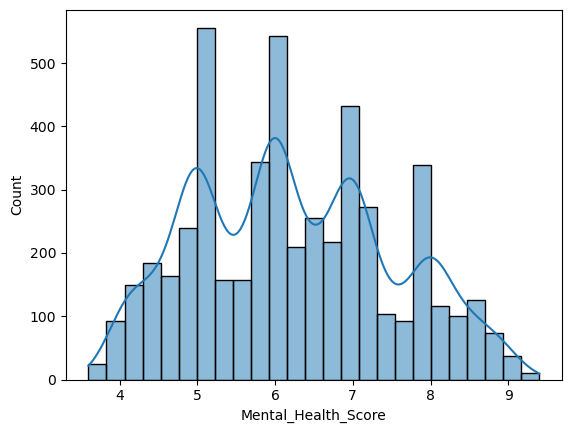

In [8]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

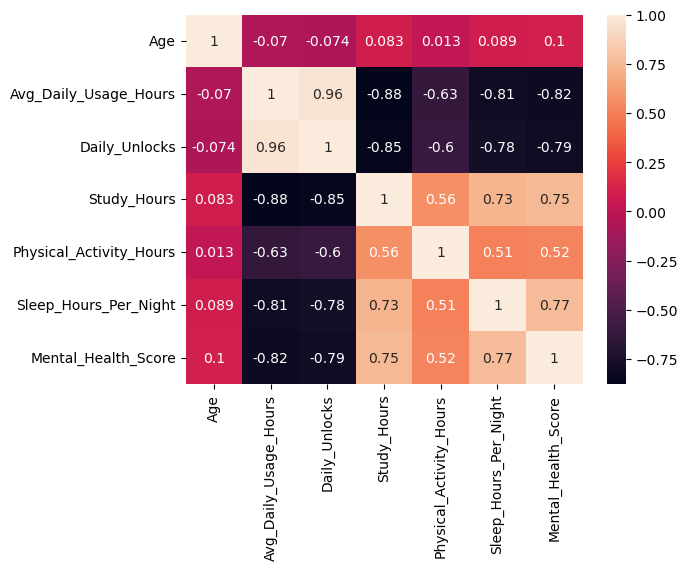

In [9]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

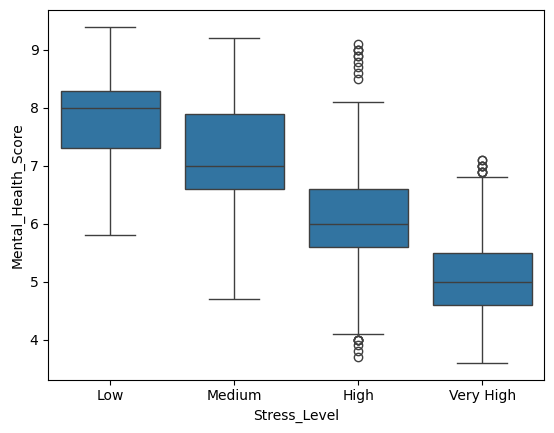

In [10]:
order = ['Low','Medium','High','Very High']
sns.boxplot(x=df['Stress_Level'],y=df['Mental_Health_Score'],order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

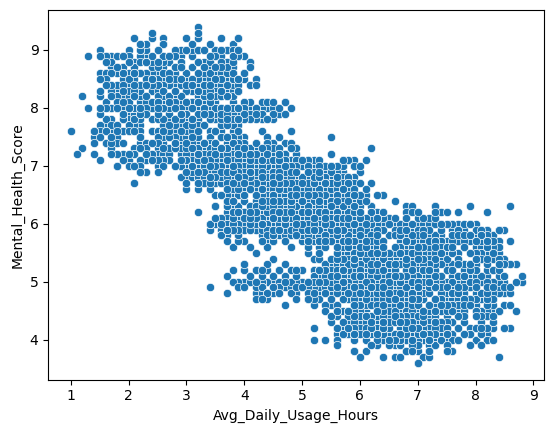

In [11]:
sns.scatterplot(x=df['Avg_Daily_Usage_Hours'],y=df['Mental_Health_Score'])

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

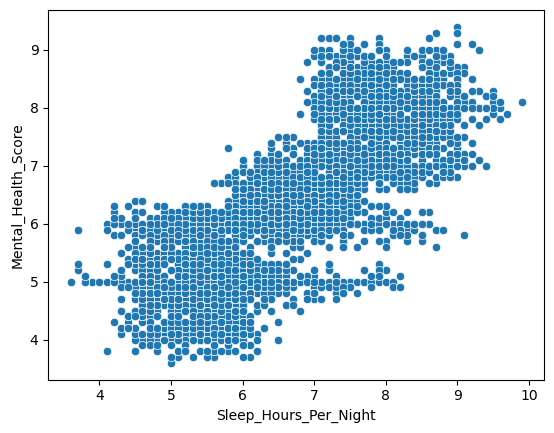

In [12]:
sns.scatterplot(x=df['Sleep_Hours_Per_Night'],y=df['Mental_Health_Score'],)

<Axes: xlabel='count', ylabel='Most_Used_Platform'>

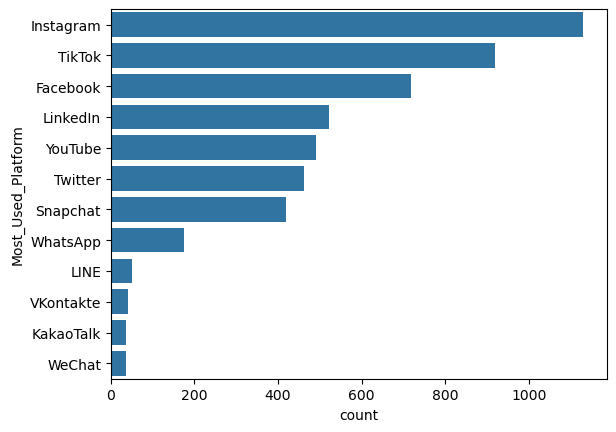

In [13]:

sns.countplot(df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)

# Outliers

In [14]:
from sympy import uppergamma


num_col = df.select_dtypes(include='number')
Q1 = num_col.quantile(0.25)
Q3 = num_col.quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (num_col<lower)|(num_col>upper)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# Data Cleaning

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.loc[df['Physical_Activity_Hours'] < 0, 'Physical_Activity_Hours'] = 0

In [17]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [18]:
num_col.skew()

Age                        0.155325
Avg_Daily_Usage_Hours      0.005606
Daily_Unlocks              0.002351
Study_Hours                0.435819
Physical_Activity_Hours    0.039971
Sleep_Hours_Per_Night      0.124050
Mental_Health_Score        0.206567
dtype: float64

In [19]:
top_countries = df['Country'].value_counts().index[1:10].to_list()

In [20]:
def group_country(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [21]:
df['Grp_country'] = df['Country'].apply(group_country)

In [22]:
df['Grp_country'].value_counts()

Grp_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

# Train-Test Split and PreProcessing

In [23]:
from sklearn.model_selection import train_test_split
skewed_col = ['Study_Hours']
numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_col  = ['Stress_Level']
normal_col   = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grp_country"]

features = skewed_col+numeric_cols+ordinal_col+normal_col
X = df[features]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer

skew_pipeline = Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])

num_pipeline = Pipeline(steps=[
    ('scaler',StandardScaler())
])

ord_pipeline = Pipeline(steps=[
    ('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])

nor_pipeline = Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('Skewed_pipeline',skew_pipeline,skewed_col),
    ('Numeric_pipeline',num_pipeline,numeric_cols),
    ('Ordinal_pipeline',ord_pipeline,ordinal_col),
    ('normal_pipeline',nor_pipeline,normal_col)
])

# Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('Regression',LinearRegression())
])

lr_pipeline.fit(X_train,y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_lr_training = lr_pipeline.predict(X_train)

lr_r2 = r2_score(y_test,y_pred_lr)
lr_r2_training = r2_score(y_train,y_pred_lr_training)

lr_mae = mean_absolute_error(y_test,y_pred_lr)
lr_mae_train= mean_absolute_error(y_train,y_pred_lr_training)

print(f'Accuracy of Testing :{lr_r2}')
print(f'Accuracy of Training :{lr_r2_training}')
print(f'MAE :{lr_mae}')


Accuracy of Testing :0.739794461743302
Accuracy of Training :0.7236771199387539
MAE :0.5361775634720182


# Random Forest

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random_forest',RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train,y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_pred_train = rf_pipeline.predict(X_train)

rf_r2 = r2_score(y_test,rf_pred)
rf_r2_train = r2_score(y_train,rf_pred_train)
rf_mae = mean_absolute_error(y_test,rf_pred)
print(f"Accuracy of Testing {rf_r2}, training {rf_r2_train}, MAE {rf_mae}")

Accuracy of Testing 0.8769929126344471, training 0.9808669071711846, MAE 0.3485739333333334


# HyperParameter Tuning

In [27]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random_forest__n_estimators'       : [100,200,300],
    'random_forest__max_depth'         : [5,10,15],
    'random_forest__min_samples_split' : [2,5,10],
    'random_forest__min_samples_leaf'  : [1,2,4]
}
random_search = RandomizedSearchCV(
    estimator= rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1

)

random_search.fit(X_train, y_train)
     

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Numeric_pipeline',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grp_country'])])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random_forest__max_depth': [5, 10, 15],
                                        'random_forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random_forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random_forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [28]:
random_search.best_params_

{'random_forest__n_estimators': 200,
 'random_forest__min_samples_split': 5,
 'random_forest__min_samples_leaf': 2,
 'random_forest__max_depth': 15}

In [29]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(X_test)
rf_best_preds_train = rf_best_pipeline.predict(X_train)
print(f"R2 Score Training for random forest after hyperparameter tuning {r2_score(y_train, rf_best_preds_train)}")
print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score Training for random forest after hyperparameter tuning 0.9547194587126759
R2 Score for random forest after hyperparameter tuning 0.8651941447944332
MAE Score for random forest after hyperparameter tuning 0.3687738303343805


In [30]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2, rf_r2, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_train, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.876993     0.980867  0.348574  0.464808
2    Random Forest (tuned)  0.865194     0.954719  0.368774  0.486590


# Save the Model


In [31]:
import joblib
joblib.dump(rf_best_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

In [32]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grp_country'],
      dtype='object')